<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Lab10/Lab%2010%3A%20Correlation%2C%20Causality%2C%20and%20Spurious%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr

start = "2010-01-01"
end = "2024-12-31"

series = {
    "CPIAUCSL": "cpi",
    "UNRATE": "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO": "indpro",
    "RSAFS": "retail_sales",
    "DGS10": "dgs10",
    "PAYEMS": "payrolls",
    "M2SL": "m2"
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1)
df = df.resample("MS").first() # monthly frequency (Month Start)
df = df.dropna() # remove missing rows

print(df.head())
print(df.shape)

                cpi  unrate  fedfunds   indpro  retail_sales  dgs10  payrolls  \
DATE                                                                            
2010-01-01  217.488     9.8      0.11  89.3426      339093.0   3.85  129802.0   
2010-02-01  217.281     9.8      0.13  89.6779      339580.0   3.68  129706.0   
2010-03-01  217.353     9.9      0.16  90.2928      346974.0   3.61  129866.0   
2010-04-01  217.403     9.9      0.20  90.5991      349869.0   3.89  130120.0   
2010-05-01  217.290     9.6      0.20  91.8230      346858.0   3.72  130642.0   

                m2  
DATE                
2010-01-01  8477.7  
2010-02-01  8527.3  
2010-03-01  8523.5  
2010-04-01  8554.8  
2010-05-01  8609.0  
(180, 8)


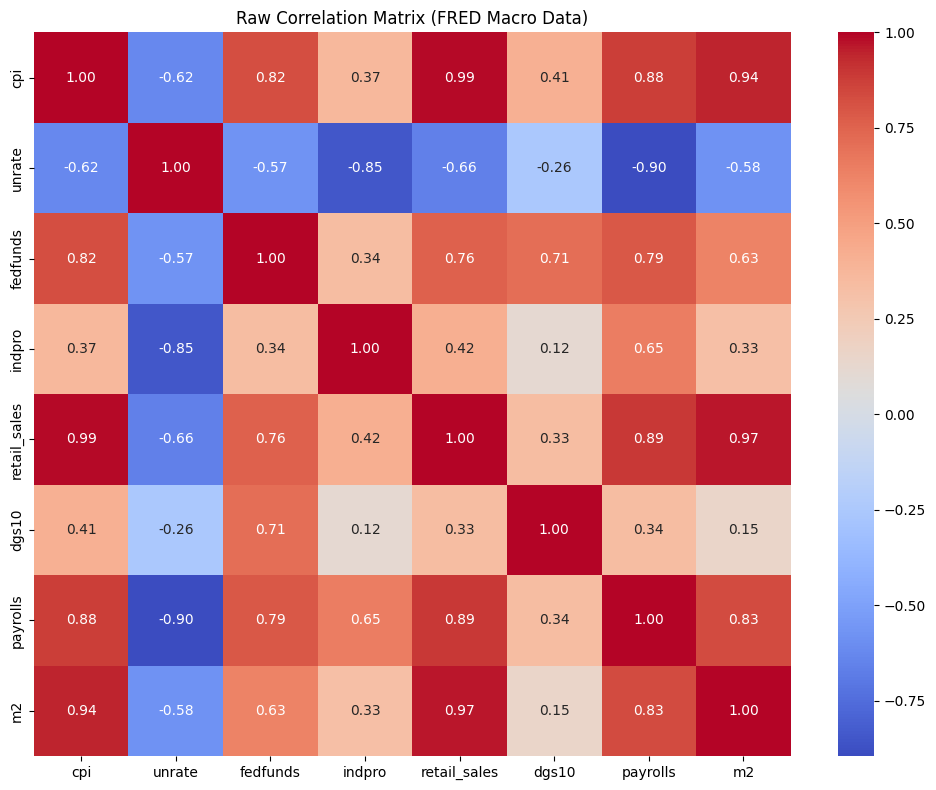

In [2]:
plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Raw Correlation Matrix (FRED Macro Data)")
plt.tight_layout()
plt.show()

In [5]:
y = df["cpi"]

X = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]]

X = sm.add_constant(X) # add intercept

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     2846.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          3.34e-174
Time:                        18:17:07   Log-Likelihood:                -429.18
No. Observations:                 180   AIC:                             874.4
Df Residuals:                     172   BIC:                             899.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -6.4462     35.511     -0.182   

In [6]:
X_vif = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]].copy()

X_vif = sm.add_constant(X_vif) # add constant

vif_table = pd.DataFrame()
vif_table["feature"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_table.sort_values("VIF", ascending=False))

        feature           VIF
0         const  31456.467322
4  retail_sales     87.871573
7            m2     82.601258
6      payrolls     73.392514
1        unrate     32.291744
2      fedfunds     16.820532
3        indpro      5.029056
5         dgs10      4.219373


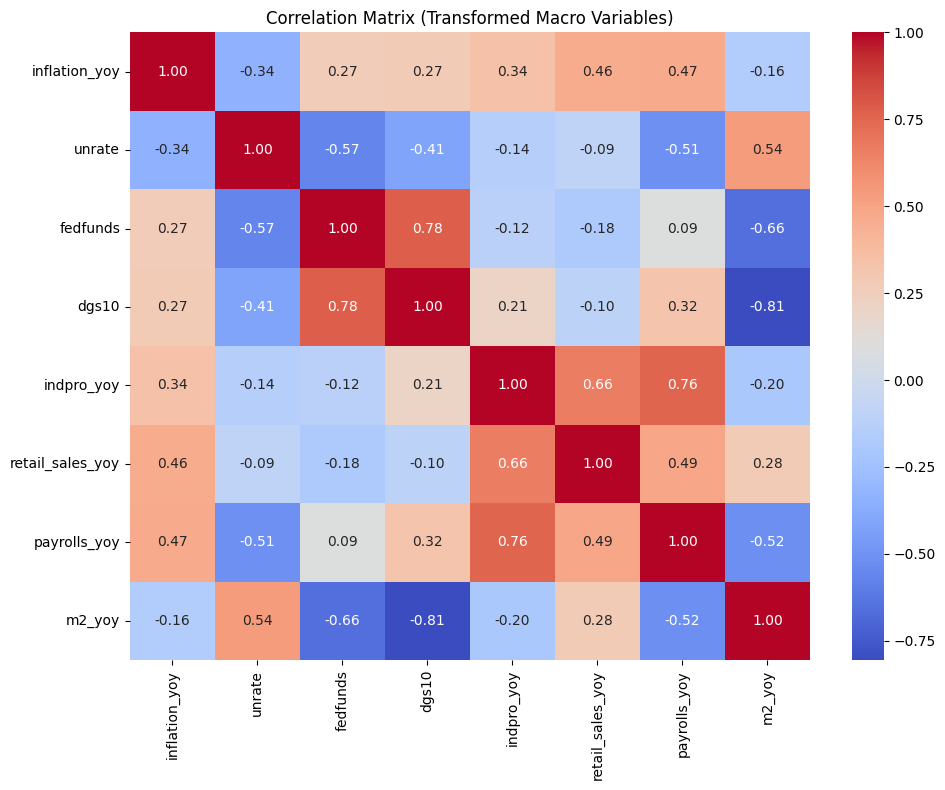

In [7]:
df_t = df.copy()

for col in ["cpi", "payrolls", "retail_sales", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = df_t[col].pct_change(12) * 100
df_t["inflation_yoy"] = df_t["cpi_yoy"]

use_cols = [
    "inflation_yoy", "unrate", "fedfunds", "dgs10",
    "indpro_yoy", "retail_sales_yoy", "payrolls_yoy", "m2_yoy"
]

df_t = df_t[use_cols].dropna() # select columns + drop NA

plt.figure(figsize=(10, 8))
sns.heatmap(df_t.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Transformed Macro Variables)")
plt.tight_layout()
plt.show()

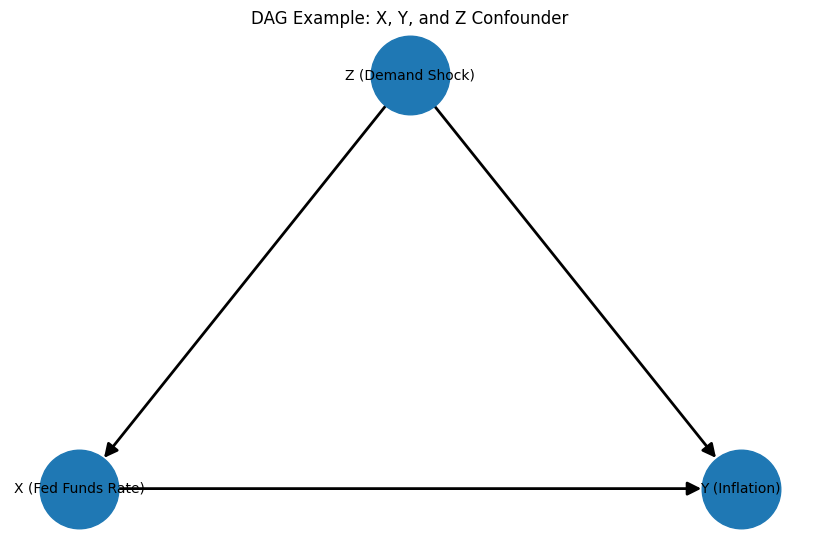

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# X = policy rate, Y = inflation, Z = confounder
G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("X (Fed Funds Rate)", "Y (Inflation)")  # optional direct causal path
])

pos = {
    "Z (Demand Shock)": (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG Example: X, Y, and Z Confounder")
plt.axis("off")
plt.show()

SPECIFICATION COMPARISON: Levels vs. YoY Growth vs. First Differences
Specification     Levels  YoY Growth  First Diff
β: const        115.4544      2.4137      0.5131
β: unrate         1.0559     -0.2109     -0.0941
β: fedfunds       6.5258      0.4449      1.0794
β: indpro         0.5758         NaN      0.0891
β: m2             0.0046         NaN      0.0002
R²                0.9819      0.2695      0.1464
Adj. R²           0.9815      0.2516      0.1267
AIC            1002.8000    667.4000    369.1000
N obs           180.0000    168.0000    179.0000
β: indpro_yoy        NaN      0.2198         NaN
β: m2_yoy            NaN      0.0989         NaN


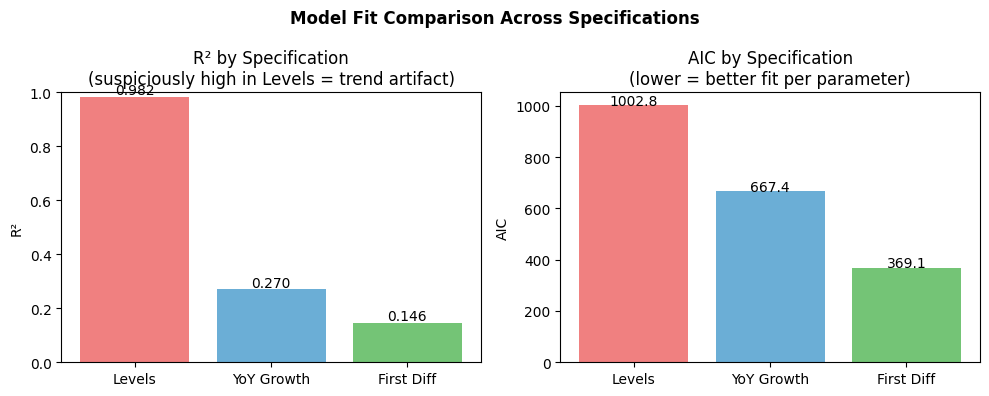

In [10]:
import pandas as pd
import statsmodels.api as sm

# ─────────────────────────────────────────────────────────────
# STEP 7: COMPARE THREE MODEL SPECIFICATIONS
# ─────────────────────────────────────────────────────────────
# We estimate the same regression three ways, changing only how
# variables are transformed. The question: do the coefficients
# and R² change meaningfully across specifications?
#
# SPEC 1 — Levels:       raw values (e.g., CPI = 280, UNRATE = 4.1)
# SPEC 2 — YoY Growth:   % change vs. same month last year (already in df_t)
# SPEC 3 — First Diff:   month-over-month change (removes trend more aggressively)
#
# SHARED PREDICTORS across all specs: unrate, fedfunds, indpro, m2
# DEPENDENT VARIABLE: CPI (or its transformation equivalent)

PREDICTORS = ["unrate", "fedfunds", "indpro", "m2"]

# ── SPECIFICATION 1: Raw Levels ──────────────────────────────
# Uses the original df built in Step 1.
# Risk: shared upward trend inflates R² artificially (the trap from Step 2).

df_levels = df[["cpi"] + PREDICTORS].dropna()

y_lev = df_levels["cpi"]
X_lev = sm.add_constant(df_levels[PREDICTORS])
model_lev = sm.OLS(y_lev, X_lev).fit()


# ── SPECIFICATION 2: Year-over-Year Growth Rates ─────────────
# Uses df_t built in Step 5. Removes trend by expressing each
# variable as % change vs. the same month one year prior.
# Captures business cycle dynamics, not just long-run drift.

df_yoy = df_t[["inflation_yoy", "unrate", "fedfunds", "indpro_yoy", "m2_yoy"]].dropna()

y_yoy = df_yoy["inflation_yoy"]
X_yoy = sm.add_constant(df_yoy[["unrate", "fedfunds", "indpro_yoy", "m2_yoy"]])
model_yoy = sm.OLS(y_yoy, X_yoy).fit()


# ── SPECIFICATION 3: First Differences ───────────────────────
# Takes the month-over-month change in each variable: Δx = x_t - x_{t-1}
# More aggressive than YoY — strips both trend AND seasonal patterns.
# Useful for stationary time series regression, but loses level information.
# Risk: amplifies short-run noise; coefficients harder to interpret economically.

df_fd = df[["cpi"] + PREDICTORS].diff().dropna()  # .diff() = x_t minus x_{t-1}

y_fd = df_fd["cpi"]
X_fd = sm.add_constant(df_fd[PREDICTORS])
model_fd = sm.OLS(y_fd, X_fd).fit()


# ─────────────────────────────────────────────────────────────
# COMPARISON TABLE: Coefficients + Fit Statistics Side by Side
# ─────────────────────────────────────────────────────────────
# We extract the key output from each model and stack them so
# differences across specifications are immediately visible.

specs = {
    "Levels":      model_lev,
    "YoY Growth":  model_yoy,
    "First Diff":  model_fd,
}

rows = []
for spec_name, model in specs.items():
    row = {"Specification": spec_name}

    # Coefficients for each predictor (rounded for readability)
    for coef_name, val in model.params.items():
        row[f"β: {coef_name}"] = round(val, 4)

    # Model fit statistics
    row["R²"]        = round(model.rsquared, 4)
    row["Adj. R²"]   = round(model.rsquared_adj, 4)
    row["AIC"]       = round(model.aic, 1)
    row["N obs"]     = int(model.nobs)
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index("Specification")

print("=" * 80)
print("SPECIFICATION COMPARISON: Levels vs. YoY Growth vs. First Differences")
print("=" * 80)
print(comparison_df.T.to_string())  # transposed so predictors are rows

# ─────────────────────────────────────────────────────────────
# VISUAL: R² and AIC Across Specifications
# ─────────────────────────────────────────────────────────────
# A high R² in Levels but low R² in First Differences is a
# classic signal that the levels model was fitting shared trend,
# not true economic relationships.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

spec_names = list(specs.keys())
r2_vals    = [m.rsquared     for m in specs.values()]
aic_vals   = [m.aic          for m in specs.values()]

# R² bar chart — higher is better, but suspiciously high = red flag
axes[0].bar(spec_names, r2_vals, color=["#f08080", "#6baed6", "#74c476"])
axes[0].set_title("R² by Specification\n(suspiciously high in Levels = trend artifact)")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# AIC bar chart — lower is better (penalizes complexity)
axes[1].bar(spec_names, aic_vals, color=["#f08080", "#6baed6", "#74c476"])
axes[1].set_title("AIC by Specification\n(lower = better fit per parameter)")
axes[1].set_ylabel("AIC")
for i, v in enumerate(aic_vals):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10)

plt.suptitle("Model Fit Comparison Across Specifications", fontweight="bold")
plt.tight_layout()
plt.show()

New YoY variables preview:
       oil_price_yoy  ppi_yoy  housing_starts_yoy  sentiment_yoy
count         168.00   168.00              168.00         168.00
mean            6.06     2.57                7.41           1.03
std            40.32     7.46               15.93          13.72
min           -68.97    -9.42              -26.42         -41.52
25%           -16.79    -2.02               -2.76          -5.95
50%             1.16     0.78                5.67           1.69
75%            20.57     5.16               15.90           9.23
max           226.88    22.69               59.72          38.83

Augmented dataset shape: (168, 12)
Date range: 2011-01-01 to 2024-12-01

Correlation of new variables with inflation_yoy:
                    inflation_yoy
oil_price_yoy               0.605
ppi_yoy                     0.793
housing_starts_yoy         -0.170
sentiment_yoy              -0.373


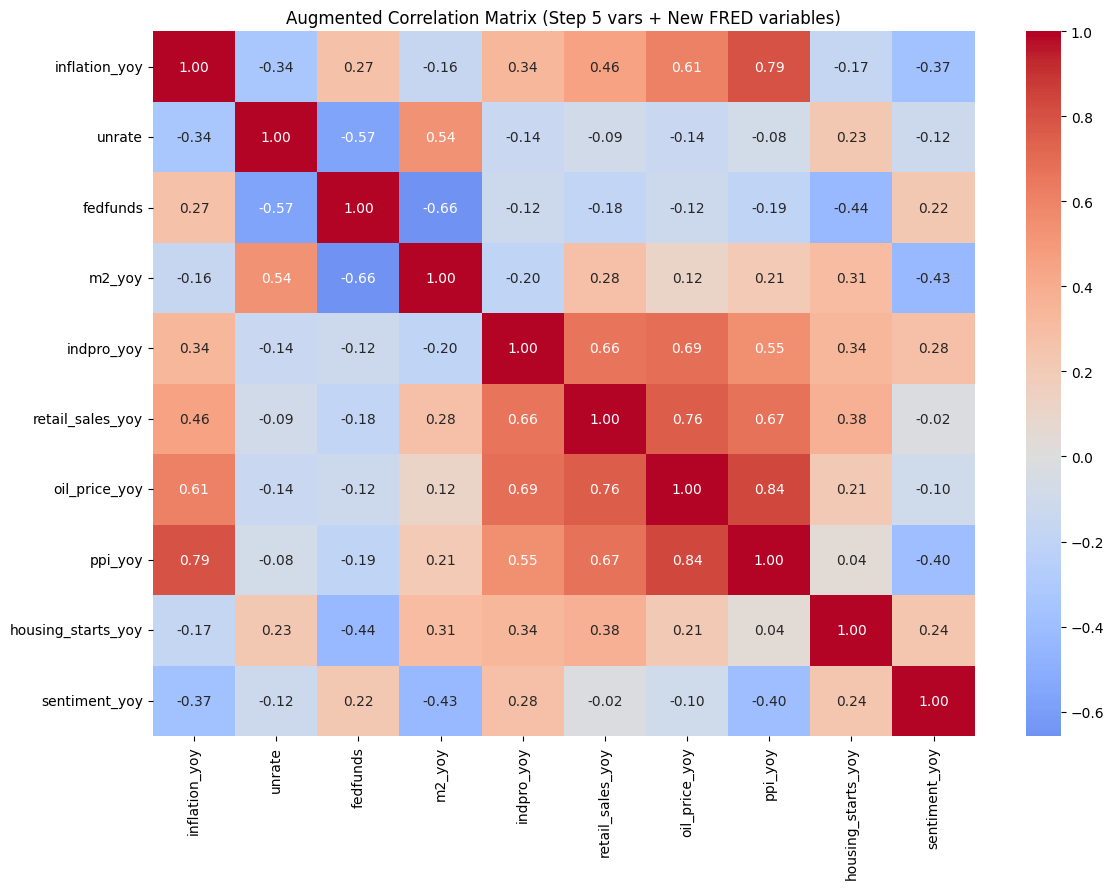

In [11]:
from pandas_datareader import data as pdr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# STEP 8: ADD NEW FRED VARIABLES RELEVANT TO INFLATION DYNAMICS
# ─────────────────────────────────────────────────────────────
# WHY THESE FOUR?
#
# 1. DCOILWTICO — WTI Crude Oil Price ($/barrel)
#    Oil is a direct input cost for transportation, manufacturing, and utilities.
#    A supply shock in oil feeds into CPI within 1–3 months. It's one of the
#    most reliable leading indicators of headline inflation — and a classic
#    example of a supply-side confounder in our DAG from Step 6.
#
# 2. PPIACO — Producer Price Index (All Commodities)
#    PPI measures prices at the WHOLESALE level, before goods reach consumers.
#    It leads CPI by roughly 2–6 months because producer cost increases get
#    passed through to retail prices with a lag. If PPI rises but CPI doesn't
#    yet, inflation is likely incoming.
#
# 3. HOUST — Housing Starts (thousands of units)
#    Shelter is the single largest component of CPI (~33%). Housing starts
#    signal future supply of housing: more starts → more supply → lower
#    shelter costs 12–24 months later. This is a long-lag disinflationary signal.
#
# 4. UMCSENT — University of Michigan Consumer Sentiment Index
#    Consumer sentiment captures whether households feel confident enough to
#    spend. High sentiment → strong demand → upward price pressure. It also
#    proxies for inflation EXPECTATIONS, the omitted variable from our DAG.

start = "2010-01-01"
end   = "2024-12-31"

new_series = {
    "DCOILWTICO": "oil_price",    # WTI crude oil, monthly average
    "PPIACO":     "ppi",          # Producer Price Index, all commodities
    "HOUST":      "housing_starts", # New residential housing units started
    "UMCSENT":    "sentiment",    # Consumer sentiment survey index
}

# Fetch each series from FRED and collect into a list
new_dfs = []
for code, name in new_series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    new_dfs.append(s)

# Combine into one DataFrame, align to month-start frequency, drop NAs
df_new = pd.concat(new_dfs, axis=1).resample("MS").first().dropna()

# ─────────────────────────────────────────────────────────────
# TRANSFORM TO YOY GROWTH RATES
# ─────────────────────────────────────────────────────────────
# We convert to YoY % change to match the transformation in Step 5.
# This removes trend and puts all variables on a comparable scale.
# EXCEPTION: sentiment is an index level (not a quantity), so YoY
# change still makes economic sense — it captures shifts in mood.

for col in ["oil_price", "ppi", "housing_starts", "sentiment"]:
    df_new[f"{col}_yoy"] = df_new[col].pct_change(12) * 100

# Drop the raw level columns — we only want the YoY versions going forward
yoy_cols = ["oil_price_yoy", "ppi_yoy", "housing_starts_yoy", "sentiment_yoy"]
df_new_yoy = df_new[yoy_cols].dropna()

print("New YoY variables preview:")
print(df_new_yoy.describe().round(2))

# ─────────────────────────────────────────────────────────────
# MERGE WITH EXISTING TRANSFORMED DATA (df_t FROM STEP 5)
# ─────────────────────────────────────────────────────────────
# We join on the date index using a left join so we don't lose
# any observations from df_t that may not align perfectly.

df_augmented = df_t.join(df_new_yoy, how="inner").dropna()

print(f"\nAugmented dataset shape: {df_augmented.shape}")
print(f"Date range: {df_augmented.index.min().date()} to {df_augmented.index.max().date()}")

# ─────────────────────────────────────────────────────────────
# CORRELATION CHECK: NEW VARIABLES VS. INFLATION
# ─────────────────────────────────────────────────────────────
# Before adding variables to a regression, always check their
# pairwise correlation with the outcome. This tells us:
# - Whether each variable carries inflation signal (useful)
# - Whether new variables are highly correlated with each other
#   (would reintroduce multicollinearity — the problem from Step 3)

inflation_corrs = df_augmented[
    ["inflation_yoy"] + yoy_cols
].corr()[["inflation_yoy"]].drop("inflation_yoy")

print("\nCorrelation of new variables with inflation_yoy:")
print(inflation_corrs.round(3))

# ─────────────────────────────────────────────────────────────
# HEATMAP: FULL AUGMENTED CORRELATION MATRIX
# ─────────────────────────────────────────────────────────────
# Compare this to the Step 5 heatmap — the new variables should
# add signal without recreating the near-1.0 correlations from Step 2.
# FLAG: If oil_price_yoy and ppi_yoy are highly correlated with each
# other (likely), including both in a regression risks multicollinearity.

aug_cols = [
    "inflation_yoy", "unrate", "fedfunds",
    "m2_yoy", "indpro_yoy", "retail_sales_yoy",
    "oil_price_yoy", "ppi_yoy", "housing_starts_yoy", "sentiment_yoy"
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    df_augmented[aug_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0
)
plt.title("Augmented Correlation Matrix (Step 5 vars + New FRED variables)", fontsize=12)
plt.tight_layout()
plt.show()